In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
url = "https://raw.githubusercontent.com/JUAN-32/datamining/refs/heads/main/archivo2/Prestige_modificado.csv"

df = pd.read_csv(url)
df = pd.read_csv(url, sep=';')



In [ ]:
# LIMPIEZA DE NOMBRES DE COLUMNAS

df.columns = df.columns.str.strip()

df.columns = df.columns.str.lower()

df.columns = df.columns.str.replace(
    " ",
    "_"
)

print("===================================")
print("COLUMNAS DEL DATASET")
print("===================================")

print(df.columns)

COLUMNAS DEL DATASET
Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')


In [ ]:
# VERIFICAR COLUMNAS IMPORTANTES


columnas_requeridas = [
    'education',
    'income',
    'women',
    'prestige',
    'census',
    'type_num'
]

print("\n===================================")
print("VERIFICACIÓN DE COLUMNAS")
print("===================================")

for columna in columnas_requeridas:

    if columna in df.columns:
        print(f"{columna} --> OK")

    else:
        print(f"{columna} --> NO EXISTE")


VERIFICACIÓN DE COLUMNAS
education --> OK
income --> OK
women --> OK
prestige --> OK
census --> OK
type_num --> OK


In [ ]:
# CONVERTIR COLUMNAS A NUMÉRICAS

for columna in columnas_requeridas:

    if columna in df.columns:

        df[columna] = pd.to_numeric(
            df[columna],
            errors='coerce'
        )

In [ ]:
# INSPECCIÓN INICIAL
print("\n===================================")
print("DIMENSIONES DEL DATASET")
print("===================================")

print(df.shape)



DIMENSIONES DEL DATASET
(102, 7)


In [ ]:
print("\n===================================")
print("PRIMERAS FILAS")
print("===================================")

print(df.head())


PRIMERAS FILAS
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [ ]:

print("\n===================================")
print("INFORMACIÓN GENERAL")
print("===================================")

print(df.info())


INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [ ]:
print("\n===================================")
print("VALORES NULOS")
print("===================================")

print(df.isnull().sum())


VALORES NULOS
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [ ]:

print("\n===================================")
print("DUPLICADOS")
print("===================================")

print(df.duplicated().sum())


DUPLICADOS
0


In [ ]:
print("\n===================================")
print("ESTADÍSTICA DESCRIPTIVA")
print("===================================")

print(df.describe())


ESTADÍSTICA DESCRIPTIVA
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  
std      0.817447  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      2.000000  
max      3.000000  


In [ ]:
# ELIMINAR FILAS CON NULOS EN VARIABLES CLAVE

df = df.dropna(
    subset=columnas_requeridas
)

In [ ]:
# REVISIÓN DE VALORES ATÍPICOS

variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("\n===================================")
print("REVISIÓN DE VALORES ATÍPICOS")
print("===================================")

for columna in variables_numericas:

    media = df[columna].mean()

    desviacion = df[columna].std()

    limite_inferior = media - (
        2 * desviacion
    )

    limite_superior = media + (
        2 * desviacion
    )

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("\n-----------------------------------")
    print("Variable:", columna)
    print("-----------------------------------")

    print(
        "Media:",
        round(media, 2)
    )

    print(
        "Desviación estándar:",
        round(desviacion, 2)
    )

    print(
        "Límite inferior:",
        round(limite_inferior, 2)
    )

    print(
        "Límite superior:",
        round(limite_superior, 2)
    )

    print(
        "Cantidad de atípicos:",
        len(atipicos)
    )



REVISIÓN DE VALORES ATÍPICOS

-----------------------------------
Variable: education
-----------------------------------
Media: 10.74
Desviación estándar: 2.73
Límite inferior: 5.28
Límite superior: 16.19
Cantidad de atípicos: 0

-----------------------------------
Variable: income
-----------------------------------
Media: 6797.9
Desviación estándar: 4245.92
Límite inferior: -1693.94
Límite superior: 15289.75
Cantidad de atípicos: 4

-----------------------------------
Variable: women
-----------------------------------
Media: 28.98
Desviación estándar: 31.72
Límite inferior: -34.47
Límite superior: 92.43
Cantidad de atípicos: 6

-----------------------------------
Variable: prestige
-----------------------------------
Media: 46.83
Desviación estándar: 17.2
Límite inferior: 12.42
Límite superior: 81.24
Cantidad de atípicos: 3

-----------------------------------
Variable: census
-----------------------------------
Media: 5401.77
Desviación estándar: 2644.99
Límite inferior: 111.79
L

In [ ]:
# MATRIZ DE CORRELACIÓN
variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
)

matriz_correlacion = variables_numericas.corr()

print("\n===================================")
print("MATRIZ DE CORRELACIÓN")
print("===================================")

print(
    matriz_correlacion.round(3)
)


MATRIZ DE CORRELACIÓN
           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000


In [ ]:
print("\n===================================")
print("CORRELACIONES CON PRESTIGE")
print("===================================")

print(
    matriz_correlacion['prestige']
    .sort_values(ascending=False)
    .round(3)
)


CORRELACIONES CON PRESTIGE
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


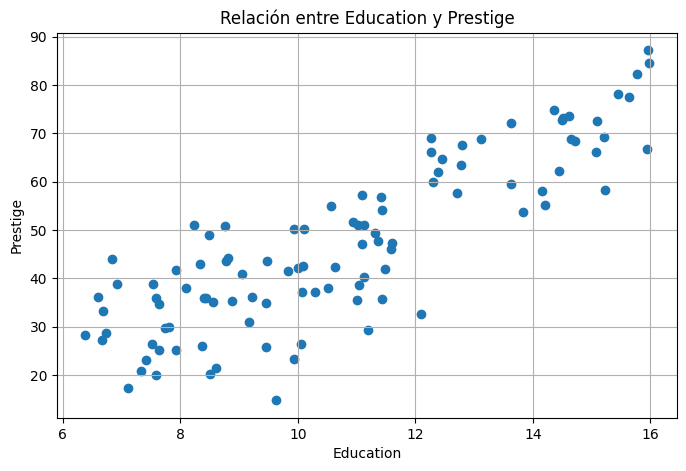

In [ ]:
# VISUALIZACIONEs
# ============================================
# EDUCATION VS PRESTIGE
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(
    df['education'],
    df['prestige']
)

plt.xlabel('Education')

plt.ylabel('Prestige')

plt.title(
    'Relación entre Education y Prestige'
)

plt.grid(True)

plt.show()

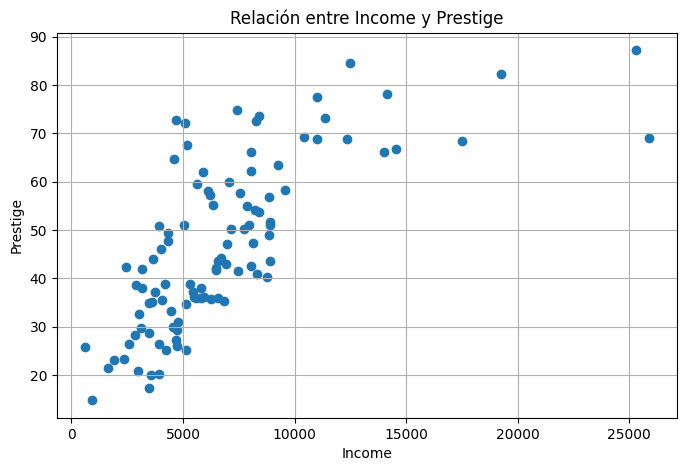

In [ ]:
# INCOME VS PRESTIGE
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(
    df['income'],
    df['prestige']
)

plt.xlabel('Income')

plt.ylabel('Prestige')

plt.title(
    'Relación entre Income y Prestige'
)

plt.grid(True)

plt.show()


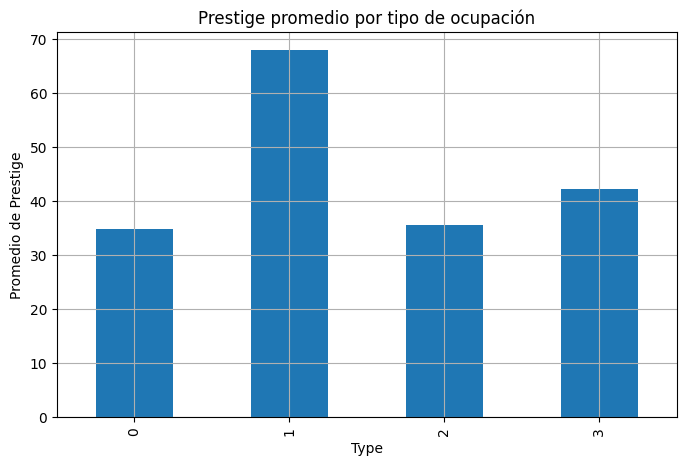

In [ ]:
# PRESTIGE POR TIPO
promedio_tipo = df.groupby(
    'type_num'
)['prestige'].mean()

plt.figure(figsize=(8,5))

promedio_tipo.plot(kind='bar')

plt.xlabel('Type')

plt.ylabel(
    'Promedio de Prestige'
)

plt.title(
    'Prestige promedio por tipo de ocupación'
)

plt.grid(True)

plt.show()

In [ ]:
# K-MEANS
# ============================================

columnas_cluster = [
    'education',
    'income',
    'women',
    'prestige',
    'type_num'
]


In [ ]:
X = df[columnas_cluster].copy()

In [ ]:
# ESCALAMIENTO
escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)

In [ ]:
# K-MEANS CON 4 CLÚSTERES
modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['cluster_4'] = modelo_k4.fit_predict(
    X_escalado
)

print("\n===================================")
print("CENTROIDES K=4")
print("===================================")

print(
    df.groupby('cluster_4')[
        columnas_cluster
    ].mean().round(2)
)


CENTROIDES K=4
           education    income  women  prestige  type_num
cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [ ]:
# K-MEANS CON 5 CLÚSTERES
modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['cluster_5'] = modelo_k5.fit_predict(
    X_escalado
)

print("\n===================================")
print("CENTROIDES K=5")
print("===================================")

print(
    df.groupby('cluster_5')[
        columnas_cluster
    ].mean().round(2)
)


CENTROIDES K=5
           education    income  women  prestige  type_num
cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


In [ ]:
# REGISTROS POR CLÚSTER
print("\n===================================")
print("REGISTROS POR CLÚSTER K=4")
print("===================================")

print(
    df['cluster_4']
    .value_counts()
)



REGISTROS POR CLÚSTER K=4
cluster_4
1    47
2    23
0    20
3    12
Name: count, dtype: int64


In [ ]:
print("\n===================================")
print("REGISTROS POR CLÚSTER K=5")
print("===================================")

print(
    df['cluster_5']
    .value_counts()
)



REGISTROS POR CLÚSTER K=5
cluster_5
1    32
3    21
2    20
0    17
4    12
Name: count, dtype: int64


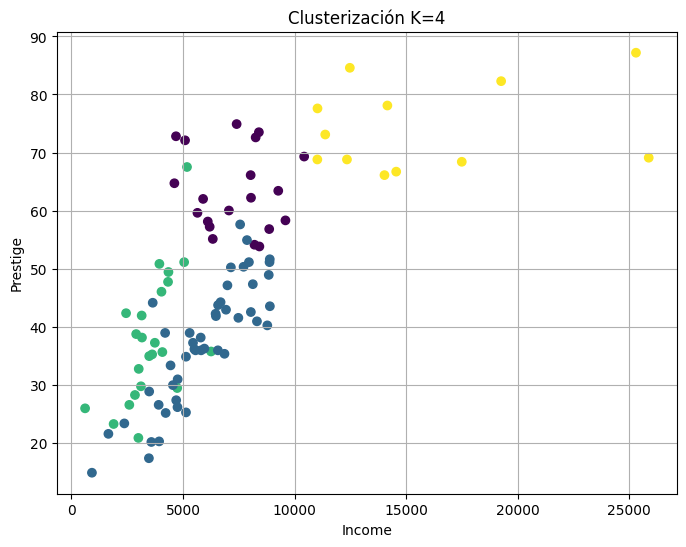

In [ ]:
# VISUALIZACIÓN DE CLÚSTERES
plt.figure(figsize=(8,6))

plt.scatter(
    df['income'],
    df['prestige'],
    c=df['cluster_4']
)

plt.xlabel('Income')

plt.ylabel('Prestige')

plt.title(
    'Clusterización K=4'
)

plt.grid(True)

plt.show()


In [ ]:
# EXPORTAR RESULTADOS
df.to_csv(
    'Prestige_resultados.csv',
    index=False
)

print("\n===================================")
print("ARCHIVO EXPORTADO CORRECTAMENTE")
print("===================================")


ARCHIVO EXPORTADO CORRECTAMENTE
